# 01 · Data Cleaning & Exploratory Data Analysis (EDA)

**Goal:** turn ~1 million raw transaction rows into a clean, trustworthy table that every later step (RFM, clustering, ML, forecasting, Power BI) can rely on.

> 📘 **Why this matters:** in real analytics jobs (and at HSBC Finance Ops, where "Data Operations" is a whole sub-function), roughly 60–80% of the effort is data preparation. Garbage in → garbage out. Interviewers love asking *"what data quality issues did you find and how did you handle them?"*. This notebook is your answer.

**Dataset:** UCI *Online Retail II*, a UK-based online gift retailer, Dec-2009 → Dec-2011. Many customers are wholesalers.

| Column | Meaning |
|---|---|
| `Invoice` | Invoice number. Starts with **"C"** = cancellation/return |
| `StockCode` | Product code |
| `Description` | Product name |
| `Quantity` | Units per line (negative for returns) |
| `InvoiceDate` | Timestamp |
| `Price` | Unit price in GBP (£) |
| `Customer ID` | Customer identifier (can be missing!) |
| `Country` | Customer country |

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
RAW = ROOT / "data" / "raw"
PROCESSED = ROOT / "data" / "processed"
FIGS = ROOT / "reports" / "figures"

sns.set_theme(style="whitegrid", palette="deep")
pd.set_option("display.float_format", "{:,.2f}".format)

## 1. Load the raw data
The Excel file has **two sheets** (2009-10 and 2010-11). We read both and stack them.
Reading a 45 MB Excel file is slow (~2-3 min), so we cache it once as **Parquet**, a fast, compressed, column-based file format used widely in industry data pipelines.

In [2]:
cache = RAW / "online_retail_raw.parquet"
if cache.exists():
    raw = pd.read_parquet(cache)
else:
    sheets = pd.read_excel(RAW / "online_retail_II.xlsx", sheet_name=None, dtype={"Invoice": str, "StockCode": str})
    raw = pd.concat(sheets.values(), ignore_index=True)
    # Some descriptions were typed as numbers in Excel → force text so Parquet has one type per column
    raw["Description"] = raw["Description"].astype("string")
    raw.to_parquet(cache, index=False)

print(f"Rows: {len(raw):,}  |  Columns: {raw.shape[1]}")
raw.head()

Rows: 1,067,371  |  Columns: 8


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,"13,085.00",United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,"13,085.00",United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,"13,085.00",United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,"13,085.00",United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,"13,085.00",United Kingdom


In [3]:
raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 1067371 entries, 0 to 1067370
Data columns (total 8 columns):
 #   Column       Non-Null Count    Dtype         
---  ------       --------------    -----         
 0   Invoice      1067371 non-null  str           
 1   StockCode    1067371 non-null  str           
 2   Description  1062989 non-null  string        
 3   Quantity     1067371 non-null  int64         
 4   InvoiceDate  1067371 non-null  datetime64[us]
 5   Price        1067371 non-null  float64       
 6   Customer ID  824364 non-null   float64       
 7   Country      1067371 non-null  str           
dtypes: datetime64[us](1), float64(2), int64(1), str(3), string(1)
memory usage: 117.3 MB


## 2. Data quality audit
Before changing anything, **measure** every problem. This becomes the "data quality" slide of your story.

In [4]:
audit = pd.Series({
    "Total rows": len(raw),
    "Missing Customer ID": raw["Customer ID"].isna().sum(),
    "Missing Description": raw["Description"].isna().sum(),
    "Exact duplicate rows": raw.duplicated().sum(),
    "Cancellation invoices (start with 'C')": raw["Invoice"].str.startswith("C").sum(),
    "Quantity <= 0": (raw["Quantity"] <= 0).sum(),
    "Price <= 0": (raw["Price"] <= 0).sum(),
})
audit_df = audit.to_frame("Rows").assign(**{"% of total": lambda d: d["Rows"] / len(raw) * 100})
audit_df

,Rows,% of total
Total rows,1067371,100.00
Missing Customer ID,243007,22.77
Missing Description,4382,0.41
Exact duplicate rows,34335,3.22
Cancellation invoices (start with 'C'),19494,1.83
Quantity <= 0,22950,2.15
Price <= 0,6207,0.58


**Non-product stock codes.** Some StockCodes are not products: postage (`POST`, `DOT`), manual adjustments (`M`), bank charges, Amazon fees, test items, etc. Including them would distort "what customers buy".
Real product codes start with 5 digits (e.g. `85123A`), so anything else is suspicious. Let's look:

In [5]:
is_product = raw["StockCode"].str.match(r"^\d{5}", na=False)
(raw.loc[~is_product]
    .groupby("StockCode")
    .agg(rows=("Invoice", "size"), example=("Description", "first"))
    .sort_values("rows", ascending=False)
    .head(15))

,rows,example
StockCode,,
POST,2122,POSTAGE
DOT,1446,DOTCOM POSTAGE
M,1421,Manual
C2,282,CARRIAGE
D,177,Discount
S,104,SAMPLES
BANK CHARGES,102,Bank Charges
ADJUST,67,Adjustment by john on 26/01/2010 16
AMAZONFEE,43,AMAZON FEE


## 3. Cleaning rules
Each rule is a **documented business decision**. You should be able to justify every one in an interview:

1. **Drop exact duplicates:** the same line recorded twice is a system glitch.
2. **Separate cancellations** (`Invoice` starts with "C"): they are *returns*, not sales. We keep them in a separate table to compute each customer's **return rate** (a useful feature later).
3. **Keep only Quantity > 0 and Price > 0** for sales: zero-price rows are samples/adjustments.
4. **Keep only real products** (5-digit StockCodes).
5. **Missing Customer ID:** keep them for *company-level revenue* (they are real sales, useful for forecasting), but exclude them from *customer-level* analysis (you can't segment an unknown customer).
6. **Create `Revenue` = Quantity × Price.**

In [6]:
df = raw.drop_duplicates().copy()
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])
df["Description"] = df["Description"].str.strip()
df = df.rename(columns={"Customer ID": "CustomerID"})

is_cancel = df["Invoice"].str.startswith("C")
is_product = df["StockCode"].str.match(r"^\d{5}", na=False)

returns = df[is_cancel & is_product].copy()
returns["ReturnValue"] = (returns["Quantity"].abs() * returns["Price"])

sales = df[~is_cancel & is_product & (df["Quantity"] > 0) & (df["Price"] > 0)].copy()
sales["Revenue"] = sales["Quantity"] * sales["Price"]

print(f"Clean sales rows: {len(sales):,}  ({len(sales)/len(raw):.1%} of raw)")
print(f"Return rows:      {len(returns):,}")

Clean sales rows: 1,003,214  (94.0% of raw)
Return rows:      17,914


**Outliers.** Let's check extreme quantities. A few single orders of 80,000+ units exist, and they were cancelled immediately (a customer mistake). Since we separated cancellations, the *original* order still sits in `sales`. We remove sales lines that have an exact matching cancellation (same customer, product, quantity).

In [7]:
sales["Quantity"].describe(percentiles=[.5, .9, .99, .999])

count   1,003,214.00
mean           11.15
std           128.75
min             1.00
50%             4.00
90%            24.00
99%           108.00
99.9%         500.00
max        80,995.00
Name: Quantity, dtype: float64

In [8]:
key = ["CustomerID", "StockCode"]
cancel_keys = returns.assign(Quantity=returns["Quantity"].abs())[key + ["Quantity"]].drop_duplicates()
big = sales["Quantity"] >= 1000   # only check large lines, typical mistakes
merged = sales[big].reset_index().merge(cancel_keys, on=key + ["Quantity"], how="inner")
mistake_idx = merged["index"].unique()
print(f"Large orders cancelled in full (removed): {len(mistake_idx)} rows, "
      f"£{sales.loc[mistake_idx, 'Revenue'].sum():,.0f} of revenue")
sales = sales.drop(index=mistake_idx)

Large orders cancelled in full (removed): 46 rows, £315,066 of revenue


## 4. Feature columns for analysis
Add date parts and a customer flag. These help both EDA and Power BI.

In [9]:
sales["Date"] = sales["InvoiceDate"].dt.normalize()
sales["YearMonth"] = sales["InvoiceDate"].dt.to_period("M").astype(str)
sales["Hour"] = sales["InvoiceDate"].dt.hour
sales["Weekday"] = sales["InvoiceDate"].dt.day_name()
sales["HasCustomer"] = sales["CustomerID"].notna()
sales["CustomerID"] = sales["CustomerID"].astype("Int64")
returns["CustomerID"] = returns["CustomerID"].astype("Int64")

print(f"Date range: {sales['InvoiceDate'].min():%d-%b-%Y} → {sales['InvoiceDate'].max():%d-%b-%Y}")
print(f"Total revenue: £{sales['Revenue'].sum():,.0f}")
print(f"Invoices: {sales['Invoice'].nunique():,} | Customers: {sales['CustomerID'].nunique():,} | "
      f"Products: {sales['StockCode'].nunique():,} | Countries: {sales['Country'].nunique()}")
print(f"Revenue from identified customers: {sales.loc[sales.HasCustomer, 'Revenue'].sum()/sales['Revenue'].sum():.1%}")

Date range: 01-Dec-2009 → 09-Dec-2011
Total revenue: £19,327,627
Invoices: 39,510 | Customers: 5,852 | Products: 4,877 | Countries: 43
Revenue from identified customers: 86.7%


## 5. Exploratory Data Analysis
EDA = asking the data simple questions before modelling. Each chart should answer **one business question**.

### Q1. How does revenue move over time? Is there seasonality?

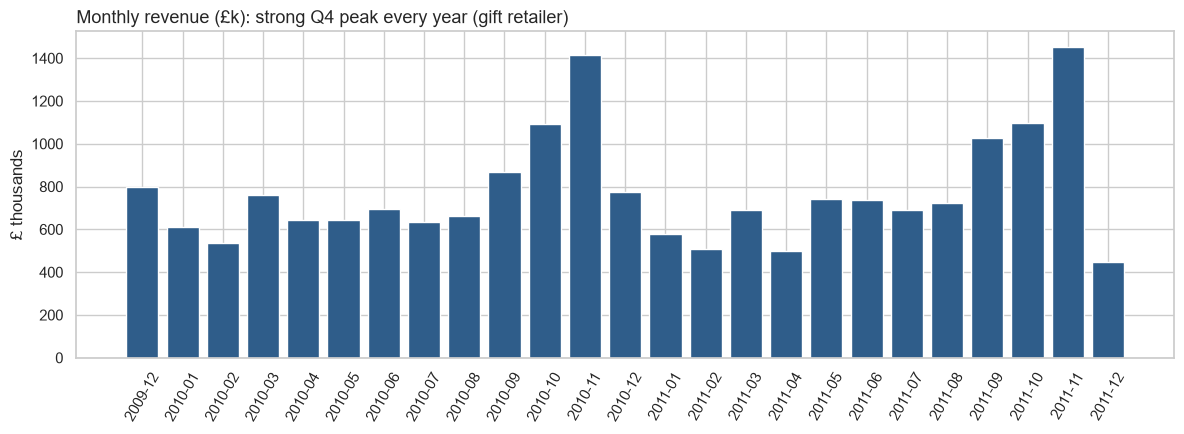

Note: Dec-2011 is a partial month (data ends 9-Dec), so it looks low.


In [10]:
monthly = sales.groupby("YearMonth").agg(Revenue=("Revenue", "sum"), Orders=("Invoice", "nunique"),
                                         Customers=("CustomerID", "nunique"))
fig, ax = plt.subplots(figsize=(12, 4.5))
ax.bar(monthly.index, monthly["Revenue"] / 1e3, color="#2F5D8A")
ax.set_title("Monthly revenue (£k): strong Q4 peak every year (gift retailer)", loc="left", fontsize=13)
ax.set_ylabel("£ thousands"); ax.tick_params(axis="x", rotation=60)
plt.tight_layout(); plt.savefig(FIGS / "01_monthly_revenue.png", dpi=150); plt.show()
print("Note: Dec-2011 is a partial month (data ends 9-Dec), so it looks low.")

**Insight:** revenue peaks in **Sep-Nov** each year (Christmas stock-up by wholesale buyers) and roughly repeats year-on-year. That seasonality matters for forecasting (notebook 06).

### Q2. Where does revenue come from geographically?

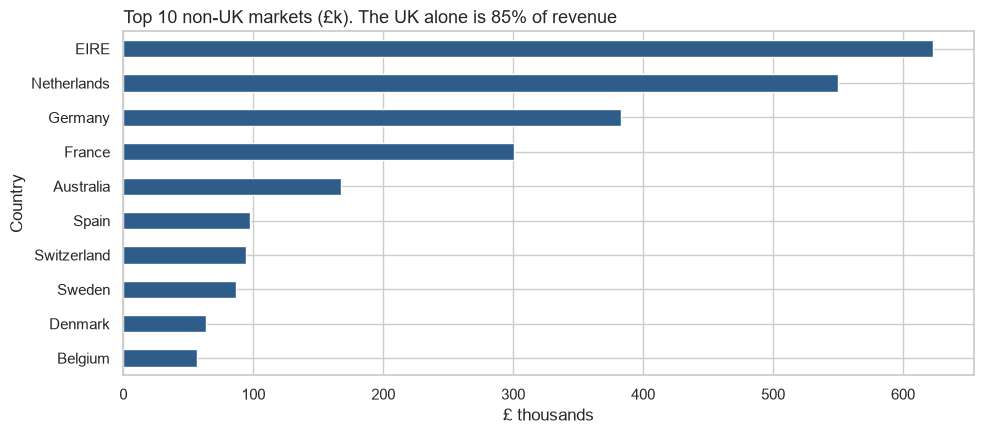

In [11]:
country = sales.groupby("Country")["Revenue"].sum().sort_values(ascending=False)
share_uk = country.iloc[0] / country.sum()
fig, ax = plt.subplots(figsize=(10, 4.5))
(country.iloc[1:11] / 1e3).sort_values().plot.barh(ax=ax, color="#2F5D8A")
ax.set_title(f"Top 10 non-UK markets (£k). The UK alone is {share_uk:.0%} of revenue", loc="left", fontsize=13)
ax.set_xlabel("£ thousands")
plt.tight_layout(); plt.savefig(FIGS / "01_top_countries.png", dpi=150); plt.show()

### Q3. Is revenue concentrated in a few customers? (Pareto / 80-20 rule)
> 📘 **Pareto principle:** often ~20% of customers drive ~80% of revenue. If true, losing a few top customers is a big **concentration risk**, a concept banks care about a lot.

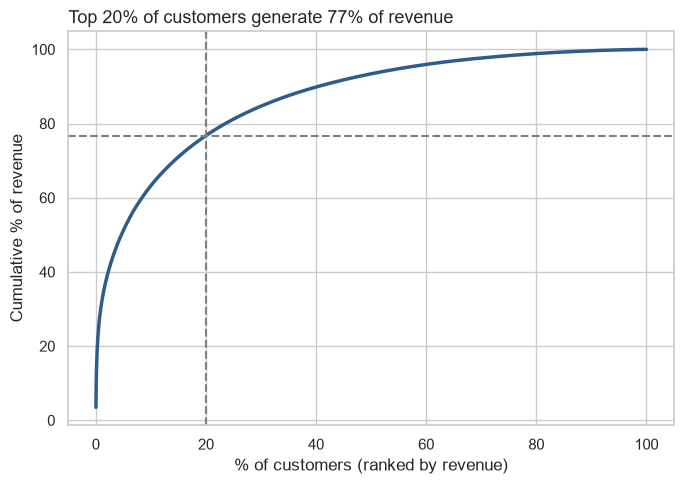

In [12]:
cust_rev = sales[sales.HasCustomer].groupby("CustomerID")["Revenue"].sum().sort_values(ascending=False)
cum_share = cust_rev.cumsum() / cust_rev.sum()
pct_customers = np.arange(1, len(cust_rev) + 1) / len(cust_rev)
top20_share = cum_share.iloc[int(len(cust_rev) * 0.2) - 1]

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(pct_customers * 100, cum_share.values * 100, color="#2F5D8A", lw=2.5)
ax.axvline(20, ls="--", color="grey"); ax.axhline(top20_share * 100, ls="--", color="grey")
ax.set_title(f"Top 20% of customers generate {top20_share:.0%} of revenue", loc="left", fontsize=13)
ax.set_xlabel("% of customers (ranked by revenue)"); ax.set_ylabel("Cumulative % of revenue")
plt.tight_layout(); plt.savefig(FIGS / "01_pareto.png", dpi=150); plt.show()

### Q4. When do customers shop? (Operational insight, e.g. staffing and campaign timing)

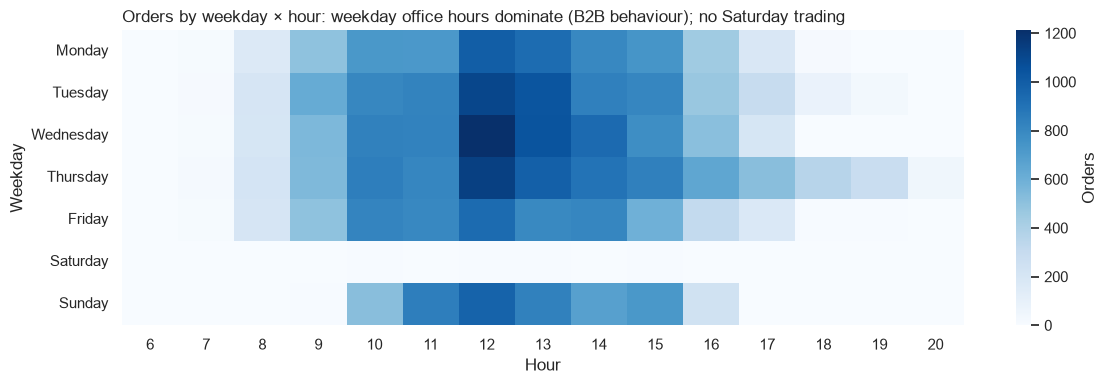

In [13]:
heat = (sales.groupby(["Weekday", "Hour"])["Invoice"].nunique().unstack(fill_value=0)
        .reindex(["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]).dropna(how="all"))
fig, ax = plt.subplots(figsize=(12, 4))
sns.heatmap(heat, cmap="Blues", ax=ax, cbar_kws={"label": "Orders"})
ax.set_title("Orders by weekday × hour: weekday office hours dominate (B2B behaviour); no Saturday trading", loc="left")
plt.tight_layout(); plt.savefig(FIGS / "01_weekday_hour.png", dpi=150); plt.show()

### Q5. Order size and returns

In [14]:
orders = sales.groupby("Invoice")["Revenue"].sum()
print(f"Average order value (AOV): £{orders.mean():,.0f}   Median: £{orders.median():,.0f}")
print("→ mean >> median means a right-skewed distribution: a few huge wholesale orders pull the average up.")
print(f"Return value as % of sales: {returns['ReturnValue'].sum() / sales['Revenue'].sum():.1%}")

Average order value (AOV): £489   Median: £301
→ mean >> median means a right-skewed distribution: a few huge wholesale orders pull the average up.
Return value as % of sales: 3.7%


## 6. Save clean outputs
Parquet for Python notebooks; CSVs for Power BI are exported in notebook 07.

In [15]:
sales.to_parquet(PROCESSED / "sales_clean.parquet", index=False)
returns.to_parquet(PROCESSED / "returns_clean.parquet", index=False)
audit_df.to_csv(PROCESSED / "data_quality_audit.csv")
print("Saved:", *[p.name for p in PROCESSED.glob("*.parquet")])

Saved: returns_clean.parquet sales_clean.parquet


## ✅ Key takeaways (write these in your own words; interviewers will ask)
1. ~23% of rows had **no Customer ID**. Kept for revenue totals, excluded from customer analytics.
2. Cancellations, non-product codes, zero prices, duplicates and cancelled bulk-mistake orders were removed with documented rules.
3. Revenue is **highly seasonal** (Q4 peak) and **concentrated** (Pareto), with the UK dominant.
4. Customers behave like **B2B buyers** (weekday, office hours, large orders).